# Deteccao zero-shot de deepfake de voz no BRSpeech-DF (pt-BR) com wav2vec 2.0 XLS-R

Este notebook testa, em **zero-shot cross-lingual**, um detector anti-spoofing baseado em
**wav2vec 2.0 / XLS-R** pre-treinado em dados majoritariamente em ingles (ASVspoof e afins) e o
aplica **diretamente** ao dataset em portugues **BRSpeech-DF**, sem nenhum treino/fine-tuning.

O pipeline segue 5 etapas, fundamentadas na literatura:

1. **Pre-processamento** do audio bruto: mono, reamostragem para 16 kHz, janela fixa de
   64.600 amostras (~4 s) e normalizacao media/variancia (Tak et al., 2022).
2. **Modelo**: front-end SSL wav2vec 2.0 XLS-R + back-end simples (pooling global + camada linear).
   Carregamos pesos ja ajustados para a tarefa; nao treinamos nada aqui.
3. **Inferencia zero-shot + robustez do mundo real**: alem do audio integro, avaliamos versoes
   degradadas (compressao MP3, codec de telefonia G.711 e ruido gaussiano).
4. **Metricas**: Equal Error Rate (EER), Matthews Correlation Coefficient (MCC) e Acuracia.
5. **Explicabilidade (XAI) no dominio do tempo**: GATR (Gradient Average Transformer Relevancy)
   e Oclusao por janela deslizante, para ver em que trechos do audio o detector se apoia.

### Referencias
- Tak et al., 2022 - *Automatic speaker verification spoofing and deepfake detection using
  wav2vec 2.0 and data augmentation* (arXiv:2202.12233).
- Channing et al., 2024 - *Toward Robust Real-World Audio Deepfake Detection: Closing the
  Explainability Gap* (arXiv:2410.07436).
- Grinberg et al., 2025 - *What Does an Audio Deepfake Detector Focus on? A Study in the Time
  Domain* (arXiv:2501.13887) - metodo GATR.
- Fullwood & Monrose, 2025 - *Seeing is Believing: Interpreting Behavioral Changes in Audio
  Deepfake Detectors Arising from Data Augmentation* (ACM AISec'25) - analise por oclusao e MCC.

> Ambiente-alvo: Google Colab (GPU T4). O checkpoint principal e um modelo XLS-R ~300M, que cabe
> confortavelmente em 16 GB de VRAM.

### Visao geral do pipeline

```mermaid
flowchart TD
    subgraph setup [1. Setup]
        Cfg["Config + set_seed()"]
    end

    subgraph data [4. Dados]
        DS["BRSpeech-DF (streaming, split test)"] --> Bal["Subconjunto balanceado N por classe"]
        Bal --> Lbl["resolve_spoof_label: verifica mapeamento"]
    end

    subgraph pre [2. Pre-processamento]
        Mono["to_mono"] --> RS["resample_to_16k"]
        RS --> Fix["fix_length: 64600 amostras"]
        Fix --> Norm["normalize_waveform: layernorm/pico"]
    end

    subgraph model [3. Modelo zero-shot]
        SSL["SSLModel: wav2vec 2.0 XLS-R (fairseq)"] --> Head["Pooling global + Linear(2)"]
        Head --> Wrap["AntiDeepfakeDetector: P(spoof)"]
    end

    Cfg --> data
    Lbl --> pre
    pre --> model

    model --> Infer["5. Inferencia zero-shot: score_audios"]

    Infer --> Metrics["6. Metricas: EER, MCC, Acuracia + matriz de confusao"]

    subgraph deg [7. Degradacoes do mundo real]
        Noise["Ruido gaussiano (SNR)"]
        Mp3["Compressao MP3"]
        G711["Telefonia G.711 mu-law"]
    end
    Infer --> deg
    deg --> Metrics

    subgraph xai [8-9. Explicabilidade no tempo]
        Gatr["GATR: atencao x gradiente -> waveform"]
        Occ["Oclusao: janela deslizante -> queda de P(spoof)"]
        Occ --> VAD["Bonus: agregacao fala vs silencio (VAD)"]
    end
    model --> xai

    Metrics --> Concl["10. Conclusoes / tabelas / graficos"]
    xai --> Concl
```

## 1. Setup: dependencias, imports e configuracao

Instalamos versoes fixadas para reprodutibilidade. O front-end SSL dos checkpoints anti-spoofing
publicos (colecao AntiDeepfake e W2V2-AASIST) e construido via **fairseq**, por isso ele e uma
dependencia obrigatoria.

**Atencao ao instalar o fairseq:** ele depende de `omegaconf<2.1`, cujos wheels tem metadata legada
que o `pip>=24.1` recusa (erro `ResolutionImpossible` / "invalid metadata"). Por isso a celula
abaixo primeiro rebaixa o pip para `<24.1` e so entao instala o fairseq. Ele tambem exige `numpy<2`;
se o Colab avisar, reinicie a sessao uma unica vez apos a instalacao.

In [1]:
import os

# No container Docker (ver Dockerfile) as dependencias ja estao instaladas na imagem e a
# variavel IN_DOCKER=1 e definida, entao pulamos a instalacao. Fora dele (ex.: Colab)
# instalamos normalmente.
if os.environ.get("IN_DOCKER"):
    print("Ambiente Docker detectado: dependencias ja instaladas na imagem; pulando %pip.")
else:
    # O fairseq 0.12.2 depende de omegaconf<2.1, cujos wheels tem metadata legada que o
    # pip>=24.1 recusa ("ResolutionImpossible"). A correcao canonica no Colab e rebaixar o pip
    # para <24.1 ANTES de instalar o fairseq.
    %pip install -q "pip<24.1"

    # Com o pip compativel, instalamos o restante. numpy<2 tambem e exigido pelo fairseq.
    %pip install -q "numpy<2" "fairseq==0.12.2" "huggingface-hub>=0.31" \
        "datasets>=2.19" "transformers>=4.40" "torchaudio" "soundfile>=0.12" \
        "scikit-learn>=1.3" "webrtcvad" "pydub" "pandas" "matplotlib" "tqdm"

    # ffmpeg (usado pelo pydub para a degradacao MP3) ja vem instalado no Colab.
    # Se estiver rodando localmente, instale-o pelo gerenciador de pacotes do seu SO.
    #
    # NOTA sobre os avisos do pip: sucesso = a linha "Building wheel for fairseq ... done".
    # Depois dela, o pip pode listar CONFLITOS de dependencia do tipo:
    #     "shap/opencv/jax/cupy/tifffile ... requires numpy>=2, but you have numpy 1.26.4".
    # Esses sao apenas AVISOS: o fairseq exige numpy<2, e esses pacotes ja pre-instalados no Colab
    # preferem numpy>=2. Como este notebook NAO usa nenhum deles, os avisos sao inofensivos.
    #
    # IMPORTANTE: por causa do downgrade de numpy, use "Runtime > Restart session" UMA vez apos esta
    # celula e entao continue a partir da celula de imports (nao precisa reinstalar).

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for webrtcvad (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      C:\Users\User\AppData\Local\Temp\pip-build-env-b5w_3kkc\overlay\Lib\site-packages\setuptools\_distutils\dist.py:288: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\User\AppData\Local\Temp\pip-build-env-b5w_3kkc\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: MIT License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ***************************************************

In [2]:
from __future__ import annotations

import dataclasses
import io
import random
import sys
import warnings
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn.functional as F
import torchaudio
import webrtcvad
from datasets import Audio, load_dataset
from huggingface_hub import PyTorchModelHubMixin
from pydub import AudioSegment
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    roc_curve,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass(frozen=True)
class Config:
    """Parametros globais do experimento, centralizados para facilitar ajuste e reproducao.

    Attributes:
        sample_rate: Taxa de amostragem exigida pelo modelo (16 kHz e o padrao para wav2vec 2.0).
        num_samples: Tamanho fixo da janela de audio, em amostras. 64.600 ~ 4,04 s a 16 kHz,
            configuracao usada por Tak et al. (2022).
        checkpoint: ID do checkpoint anti-spoofing no Hugging Face Hub (front-end + back-end).
        dataset_id: ID do dataset em portugues no Hugging Face Hub.
        dataset_config: Nome da configuracao do dataset.
        eval_split: Split usado para avaliacao (zero-shot, sem treino).
        n_per_class: Numero de audios por classe (bonafide/spoof) no subconjunto balanceado.
        seed: Semente global de aleatoriedade.
        device: "cuda" se houver GPU disponivel, senao "cpu".
    """

    sample_rate: int = 16_000
    num_samples: int = 64_600
    checkpoint: str = "nii-yamagishilab/mms-300m-anti-deepfake"
    dataset_id: str = "AKCIT-Deepfake/BRSpeech-DF"
    dataset_config: str = "default"
    eval_split: str = "test"
    n_per_class: int = 200
    seed: int = 42
    device: str = field(default_factory=lambda: "cuda" if torch.cuda.is_available() else "cpu")


CFG = Config()


def set_seed(seed: int = CFG.seed) -> None:
    """Fixa as sementes de aleatoriedade de Python, NumPy e PyTorch.

    Garante que a amostragem do dataset, a adicao de ruido e qualquer outra operacao
    estocastica sejam reproduziveis entre execucoes.

    Args:
        seed: Valor da semente a ser aplicado em todas as bibliotecas.

    Returns:
        None. O efeito e colateral (altera o estado global dos geradores).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
# Sanidade do ambiente: o fairseq exige numpy<2. Se o import de torch/torchaudio acima falhou
# com erro de ABI do numpy, reinicie a sessao (Runtime > Restart session) e rode esta celula de novo.
assert np.__version__.startswith("1."), (
    f"numpy {np.__version__} detectado; o fairseq precisa de numpy<2. "
    "Rode a celula de instalacao e reinicie a sessao."
)
print(f"numpy / torch  : {np.__version__} / {torch.__version__}")
print(f"Dispositivo    : {CFG.device}")
print(f"Checkpoint     : {CFG.checkpoint}")
print(f"Janela de audio: {CFG.num_samples} amostras (~{CFG.num_samples / CFG.sample_rate:.2f} s)")

c:\Users\User\VSCode\Projetos\CyberSec\AudioVoiceDeepFake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy / torch  : 1.26.4 / 2.13.0+cu130
Dispositivo    : cuda
Checkpoint     : nii-yamagishilab/mms-300m-anti-deepfake
Janela de audio: 64600 amostras (~4.04 s)


## 2. Pre-processamento do audio bruto

O wav2vec 2.0 recebe a **forma de onda bruta** diretamente. Padronizamos todo audio em quatro
passos, todos implementados como funcoes puras (facil de testar e depurar):

1. `to_mono` - colapsa canais estereo em mono.
2. `resample_to_16k` - reamostra para 16 kHz.
3. `fix_length` - corta ou repete (tile) para exatamente 64.600 amostras.
4. `normalize_waveform` - normalizacao media/variancia (`layer_norm`, padrao dos checkpoints
   AntiDeepfake) ou, opcionalmente, normalizacao de pico.

`preprocess` encadeia os quatro passos e e a unica funcao chamada no restante do notebook.

In [3]:
def to_mono(waveform: torch.Tensor) -> torch.Tensor:
    """Converte uma forma de onda para canal unico (mono).

    Args:
        waveform: Tensor de audio. Pode ter shape (amostras,), (canais, amostras)
            ou (1, amostras).

    Returns:
        Tensor 1-D (amostras,) contendo a media dos canais.
    """
    if waveform.ndim == 2:
        waveform = waveform.mean(dim=0)
    return waveform.reshape(-1)


def resample_to_16k(waveform: torch.Tensor, orig_sr: int, target_sr: int = CFG.sample_rate) -> torch.Tensor:
    """Reamostra a forma de onda para a taxa alvo (16 kHz por padrao).

    Args:
        waveform: Tensor 1-D de audio.
        orig_sr: Taxa de amostragem original do audio, em Hz.
        target_sr: Taxa de amostragem desejada, em Hz.

    Returns:
        Tensor 1-D reamostrado. Se `orig_sr == target_sr`, retorna o tensor inalterado.
    """
    if orig_sr == target_sr:
        return waveform
    return torchaudio.functional.resample(waveform, orig_freq=orig_sr, new_freq=target_sr)


def fix_length(waveform: torch.Tensor, num_samples: int = CFG.num_samples) -> torch.Tensor:
    """Ajusta a forma de onda para um numero exato de amostras.

    Se o audio for mais longo, mantem apenas as primeiras `num_samples` amostras (janela
    deterministica, igual a usada na avaliacao de Tak et al.). Se for mais curto, repete o
    sinal (tile) ate atingir o tamanho e entao corta o excedente.

    Args:
        waveform: Tensor 1-D de audio.
        num_samples: Comprimento fixo desejado, em amostras.

    Returns:
        Tensor 1-D com exatamente `num_samples` amostras.
    """
    length = waveform.shape[0]
    if length >= num_samples:
        return waveform[:num_samples]
    n_repeats = num_samples // length + 1
    return waveform.repeat(n_repeats)[:num_samples]


def normalize_waveform(waveform: torch.Tensor, mode: str = "layernorm") -> torch.Tensor:
    """Normaliza a forma de onda antes de alimentar o modelo.

    Args:
        waveform: Tensor 1-D de audio.
        mode: Estrategia de normalizacao:
            - "layernorm": normalizacao media/variancia (equivalente a
              `torch.nn.functional.layer_norm`), usada pelos checkpoints AntiDeepfake.
            - "peak": normalizacao de pico (divide pelo maximo valor absoluto), citada por
              Tak et al. como alternativa.

    Returns:
        Tensor 1-D normalizado.

    Raises:
        ValueError: Se `mode` nao for "layernorm" nem "peak".
    """
    if mode == "layernorm":
        return F.layer_norm(waveform, waveform.shape)
    if mode == "peak":
        peak = waveform.abs().max()
        return waveform / peak if peak > 0 else waveform
    raise ValueError(f"mode invalido: {mode!r}. Use 'layernorm' ou 'peak'.")


def preprocess(
    audio_array: np.ndarray,
    orig_sr: int,
    num_samples: int = CFG.num_samples,
    norm_mode: str = "layernorm",
) -> torch.Tensor:
    """Aplica o pipeline completo de pre-processamento a um array de audio.

    Encadeia: mono -> reamostragem 16 kHz -> janela fixa -> normalizacao.

    Args:
        audio_array: Audio bruto como array NumPy (float). 1-D ou (canais, amostras).
        orig_sr: Taxa de amostragem original, em Hz.
        num_samples: Comprimento fixo de saida, em amostras.
        norm_mode: Estrategia de normalizacao repassada a `normalize_waveform`.

    Returns:
        Tensor 1-D `float32` pronto para o modelo, com `num_samples` amostras a 16 kHz.
    """
    waveform = torch.as_tensor(audio_array, dtype=torch.float32)
    waveform = to_mono(waveform)
    waveform = resample_to_16k(waveform, orig_sr)
    waveform = fix_length(waveform, num_samples)
    waveform = normalize_waveform(waveform, mode=norm_mode)
    return waveform


# Verificacao rapida do pipeline com um sinal senoidal sintetico.
_demo = preprocess(np.sin(np.linspace(0, 100, 8000)).astype(np.float32), orig_sr=8_000)
print(f"preprocess OK -> shape={tuple(_demo.shape)} | media={_demo.mean():.3e} | std={_demo.std():.3f}")

preprocess OK -> shape=(64600,) | media=1.311e-08 | std=1.000


## 3. Modelo: front-end XLS-R + back-end simples (pooling + linear)

Reproduzimos a arquitetura dos checkpoints **AntiDeepfake** (Yamagishi Lab): um front-end SSL
wav2vec 2.0 (construido via fairseq) seguido de um back-end minimalista `AdaptiveAvgPool1d + Linear`,
exatamente o "back-end de baixo esforco" descrito por Tak et al. (2022). Os pesos ja vem ajustados
para a tarefa; **nao treinamos nada**.

O modelo devolve 2 logits. Convencao do checkpoint AntiDeepfake: **classe 0 = fake (spoof)** e
**classe 1 = real (bonafide)**. O wrapper `AntiDeepfakeDetector` padroniza a saida expondo sempre a
**probabilidade de spoof**, alem de dar acesso as camadas do transformer (necessario para o GATR).

O `checkpoint` e trocavel: alem do `mms-300m-anti-deepfake` (multilingue), qualquer modelo da
mesma familia (ex.: `wav2vec-large-anti-deepfake`) usa a mesma classe. Ao final ha um bloco
**comentado** mostrando como usar o `W2V2-AASIST` (XLS-R treinado so em ASVspoof/ingles), que segue
uma narrativa zero-shot cross-lingual mais "pura", porem com back-end AASIST.

> Nota de compatibilidade: o fairseq 0.12.2 e o hydra 1.0.x nao importam em Python >= 3.11 por
> causa de defaults mutaveis em dataclasses. A funcao `install_dataclass_mutable_default_shim()`
> (no inicio da celula abaixo) instala um shim no modulo `dataclasses` que converte esses defaults
> em `field(default_factory=...)` automaticamente, cobrindo fairseq, hydra e omegaconf de uma vez.

In [4]:
# --- Compatibilidade fairseq/hydra x Python >= 3.11 --------------------------------------------
# Em Python 3.11+, @dataclass proibe default mutavel (instancia de dataclass, dict, list, ...),
# quebrando o import do fairseq 0.12.2 E do hydra 1.0.x com:
#   "ValueError: mutable default ... is not allowed: use default_factory".
# Em vez de editar arquivo por arquivo (fairseq, hydra, omegaconf...), instalamos um shim no
# proprio modulo `dataclasses`: ao detectar um campo com default mutavel, convertemos para
# field(default_factory=...) automaticamente. Cobre todos os pacotes de uma vez. Idempotente.
def install_dataclass_mutable_default_shim() -> bool:
    """Permite dataclasses com defaults mutaveis (comportamento pre-3.11) via monkeypatch.

    Envolve `dataclasses._get_field`. Trata SOMENTE o padrao que quebra fairseq/hydra: um campo
    cujo default e uma INSTANCIA de dataclass nao-hashable (esteja "cru" no atributo ou embrulhado
    em `field(default=...)`). Nesse caso, torna a classe do default hashable, o que satisfaz a
    checagem do @dataclass e PRESERVA a instancia em `.default` - essencial porque o fairseq le
    `FairseqConfig.__dataclass_fields__[k].default` diretamente no `hydra_init`.

    Defaults mutaveis que NAO sao dataclass (dict/list) e campos ClassVar/InitVar sao deixados
    intactos, para nao interferir em bibliotecas como `datasets` (que usa ClassVar com lista).
    Necessario para importar fairseq 0.12.2 e hydra 1.0.x em Python 3.11+.

    Returns:
        True se o shim foi instalado agora; False se ja estava instalado.
    """
    if getattr(dataclasses, "_mutable_default_shim_installed", False):
        return False
    original_get_field = dataclasses._get_field

    def _get_field_with_shim(cls, a_name, a_type, *args, **kwargs):
        raw = getattr(cls, a_name, dataclasses.MISSING)
        # O default problematico do fairseq/hydra pode estar "cru" no atributo OU embrulhado em
        # field(default=...). Tratamos APENAS instancias de dataclass; dict/list/ClassVar ficam
        # intocados para nao quebrar libs como `datasets` (que usa ClassVar com default de lista).
        candidate = raw.default if isinstance(raw, dataclasses.Field) else raw
        if (
            candidate is not dataclasses.MISSING
            and not isinstance(candidate, type)
            and dataclasses.is_dataclass(candidate)
            and getattr(type(candidate), "__hash__", None) is None
        ):
            # Torna a classe hashable e preserva a instancia em `.default` (o fairseq le isso).
            type(candidate).__hash__ = object.__hash__
        return original_get_field(cls, a_name, a_type, *args, **kwargs)

    dataclasses._get_field = _get_field_with_shim
    dataclasses._mutable_default_shim_installed = True
    return True


def reset_modules(prefixes: tuple[str, ...]) -> None:
    """Remove de `sys.modules` os modulos cujos nomes comecam pelos prefixos dados.

    Um import que falhou antes deixa modulos parcialmente carregados em cache; limpa-los permite
    reimportar fairseq/hydra do zero, agora com o shim ativo.

    Args:
        prefixes: Prefixos de nomes de modulo a limpar (ex.: ("fairseq", "hydra")).

    Returns:
        None.
    """
    for name in [m for m in sys.modules if m.startswith(prefixes)]:
        del sys.modules[name]


install_dataclass_mutable_default_shim()
reset_modules(("fairseq", "hydra"))

# NOTA: o import do fairseq precisa ficar aqui (nao no bloco de imports da secao 1): so pode
# acontecer DEPOIS do shim de dataclasses + reset_modules acima, senao quebra em Python 3.11+.
from fairseq.models.wav2vec import Wav2Vec2Config, Wav2Vec2Model


class SSLModel(torch.nn.Module):
    """Front-end wav2vec 2.0 (XLS-R / large ~300M) construido via fairseq.

    A arquitetura e criada com pesos aleatorios; os pesos reais sao carregados depois, junto com
    o back-end, por `DeepfakeDetector.from_pretrained`. A config abaixo corresponde a arquitetura
    "large" de 24 camadas (embed_dim=1024), compativel com os checkpoints AntiDeepfake de ~300M
    (mms-300m e wav2vec-large).
    """

    def __init__(self) -> None:
        super().__init__()
        cfg = Wav2Vec2Config(
            quantize_targets=True,
            extractor_mode="layer_norm",
            layer_norm_first=True,
            final_dim=768,
            latent_temp=(2.0, 0.1, 0.999995),
            encoder_layerdrop=0.0,
            dropout_input=0.0,
            dropout_features=0.0,
            dropout=0.0,
            attention_dropout=0.0,
            conv_bias=True,
            encoder_layers=24,
            encoder_embed_dim=1024,
            encoder_ffn_embed_dim=4096,
            encoder_attention_heads=16,
            feature_grad_mult=1.0,
        )
        self.model = Wav2Vec2Model(cfg)

    def extract_feat(self, input_data: torch.Tensor) -> torch.Tensor:
        """Extrai as features por frame do encoder do wav2vec 2.0.

        Diferente do exemplo oficial, NAO usamos `torch.no_grad()` aqui: o GATR precisa que os
        gradientes fluam pelo transformer. Quem quiser apenas inferencia deve envolver a chamada
        em `torch.inference_mode()` externamente.

        Args:
            input_data: Tensor de forma (B, T) ou (B, T, 1) com o audio bruto normalizado.

        Returns:
            Tensor de features de forma (B, T', D), onde T' e o numero de frames e D o tamanho
            do embedding (1024 para modelos large).
        """
        if input_data.ndim == 3:
            input_data = input_data[:, :, 0]
        return self.model(input_data, mask=False, features_only=True)["x"]


class DeepfakeDetector(torch.nn.Module, PyTorchModelHubMixin):
    """Detector = front-end SSL + back-end (pooling global + camada linear de 2 classes).

    Estrutura identica a dos checkpoints AntiDeepfake, o que permite carregar os pesos via
    `from_pretrained`. Saida: logits de 2 classes (0 = fake, 1 = real).
    """

    def __init__(self) -> None:
        super().__init__()
        self.ssl_orig_output_dim = 1024
        self.num_classes = 2
        self.m_ssl = SSLModel()
        self.adap_pool1d = torch.nn.AdaptiveAvgPool1d(output_size=1)
        self.proj_fc = torch.nn.Linear(self.ssl_orig_output_dim, self.num_classes)

    def forward(self, wav: torch.Tensor) -> torch.Tensor:
        """Calcula os logits de 2 classes para um lote de formas de onda.

        Args:
            wav: Tensor de audio de forma (B, T), normalizado e a 16 kHz.

        Returns:
            Tensor de logits de forma (B, 2). Indice 0 = fake, indice 1 = real.
        """
        emb = self.m_ssl.extract_feat(wav)   # (B, T', D)
        emb = emb.transpose(1, 2)            # (B, D, T')
        pooled = self.adap_pool1d(emb).squeeze(-1)  # (B, D)
        return self.proj_fc(pooled)         # (B, 2)


class AntiDeepfakeDetector:
    """Wrapper de alto nivel que padroniza o uso do detector no restante do notebook.

    Esconde detalhes do checkpoint (convencao de rotulos, device, pre-processamento) e expoe
    sempre a *probabilidade de spoof*, deixando as metricas e a XAI agnosticas ao modelo.

    Attributes:
        model: Instancia de `DeepfakeDetector` ja com os pesos carregados.
        spoof_index: Indice da classe "spoof" na saida de logits.
        device: Dispositivo em que o modelo roda.
    """

    def __init__(self, model: DeepfakeDetector, spoof_index: int = 0, device: str = CFG.device) -> None:
        self.model = model.to(device).eval()
        self.spoof_index = spoof_index
        self.device = device

    @property
    def transformer_layers(self) -> torch.nn.ModuleList:
        """Camadas de auto-atencao do encoder (usadas pelos hooks do GATR).

        Returns:
            `ModuleList` com as `TransformerSentenceEncoderLayer` do front-end fairseq.
        """
        return self.model.m_ssl.model.encoder.layers

    def logits(self, waveform: torch.Tensor) -> torch.Tensor:
        """Passa um lote de formas de onda pelo modelo mantendo o grafo de gradientes.

        Args:
            waveform: Tensor (B, T) normalizado, no mesmo device do modelo.

        Returns:
            Tensor de logits (B, 2), diferenciavel (util para o GATR).
        """
        return self.model(waveform)

    @torch.inference_mode()
    def spoof_prob_tensor(self, waveform: torch.Tensor) -> torch.Tensor:
        """Probabilidade de spoof para um lote ja pre-processado (sem gradientes).

        Args:
            waveform: Tensor (B, T) normalizado, a 16 kHz.

        Returns:
            Tensor 1-D (B,) com a probabilidade de spoof de cada amostra.
        """
        probs = F.softmax(self.model(waveform.to(self.device)), dim=1)
        return probs[:, self.spoof_index]

    def spoof_prob(self, audio_array: np.ndarray, orig_sr: int) -> float:
        """Probabilidade de spoof de um unico audio bruto (pipeline completo).

        Args:
            audio_array: Audio bruto como array NumPy.
            orig_sr: Taxa de amostragem original do audio, em Hz.

        Returns:
            Probabilidade de spoof no intervalo [0, 1].
        """
        wav = preprocess(audio_array, orig_sr).unsqueeze(0)
        return float(self.spoof_prob_tensor(wav).item())


def build_detector(checkpoint: str = CFG.checkpoint, spoof_index: int = 0) -> AntiDeepfakeDetector:
    """Carrega um checkpoint anti-spoofing e devolve o wrapper pronto para uso.

    Args:
        checkpoint: ID do modelo no Hugging Face Hub (familia AntiDeepfake).
        spoof_index: Indice da classe spoof na saida (0 para os checkpoints AntiDeepfake).

    Returns:
        Um `AntiDeepfakeDetector` em modo de avaliacao, no device configurado.
    """
    model = DeepfakeDetector.from_pretrained(checkpoint)
    return AntiDeepfakeDetector(model, spoof_index=spoof_index, device=CFG.device)


detector = build_detector()
n_params = sum(p.numel() for p in detector.model.parameters())
print(f"Modelo carregado: {CFG.checkpoint}")
print(f"Parametros      : {n_params / 1e6:.1f} M")
print(f"Camadas transformer (GATR): {len(detector.transformer_layers)}")

# -------------------------------------------------------------------------------------------
# ALTERNATIVA (zero-shot cross-lingual "puro", XLS-R treinado so em ASVspoof/ingles):
# W2V2-AASIST usa um back-end AASIST proprio e nao a classe DeepfakeDetector acima, entao exige
# baixar os arquivos de rede do repositorio. Descomente para usar (mais pesado no Colab):
#
#   !git clone https://huggingface.co/SpeechAntiSpoofingBenchmarks/W2V2-AASIST
#   # ... importar W2V2AASIST de w2v2_aasist.py e adaptar um wrapper com a mesma interface
#   #     (transformer_layers / logits / spoof_prob). A classe positiva de bonafide e o indice 1,
#   #     logo spoof_index=0 aqui tambem, apos converter o score para probabilidade.
# -------------------------------------------------------------------------------------------

2026-07-09 17:29:49 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/nii-yamagishilab/mms-300m-anti-deepfake/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-09 17:29:49 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nii-yamagishilab/mms-300m-anti-deepfake/7928e119e09f616b2ce698892e00ca22dbaa40bf/config.json "HTTP/1.1 200 OK"
c:\Users\User\VSCode\Projetos\CyberSec\AudioVoiceDeepFake\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
2026-07-09 17:29:54 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/nii-yamagishilab/mms-300m-anti-deepfake/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Modelo carregado: nii-yamagishilab/mms-300m-anti-deepfake
Parametros      : 317.4 M
Camadas transformer (GATR): 24


## 4. Dados: BRSpeech-DF (portugues) em streaming

Carregamos o split de **teste** em modo streaming (sem baixar tudo) e montamos um subconjunto
**balanceado** (`n_per_class` audios por classe). Antes de qualquer metrica, inspecionamos e
**imprimimos o mapeamento de rotulos** do dataset para saber com certeza qual inteiro representa
"spoof" e qual representa "bonafide" - esse ponto e uma fonte classica de bugs.

Guardamos as formas de onda **brutas** (nao pre-processadas), para reutiliza-las nas degradacoes
e na analise de explicabilidade.

In [5]:
def decode_audio(audio_field) -> tuple[np.ndarray, int]:
    """Decodifica o campo de audio do dataset sem depender do torchcodec.

    Versoes recentes do `datasets` exigem o `torchcodec` para decodificar a feature `Audio`,
    e ele nao tem build compativel com o torch desta imagem. Por isso carregamos a coluna com
    `Audio(decode=False)` (que entrega bytes/caminho crus) e decodificamos aqui com `soundfile`.

    Args:
        audio_field: Valor da coluna "audio" com `decode=False`; um dict com as chaves
            "bytes" e/ou "path".

    Returns:
        Tupla `(waveform, sample_rate)` com o audio em float32 e sua taxa de amostragem nativa.
    """
    data = audio_field.get("bytes")
    source = io.BytesIO(data) if data is not None else audio_field["path"]
    waveform, sample_rate = sf.read(source, dtype="float32", always_2d=False)
    return np.asarray(waveform, dtype=np.float32), int(sample_rate)


def resolve_spoof_label(dataset_split) -> tuple[int, dict[int, str]]:
    """Descobre qual valor inteiro do rotulo corresponde a "spoof".

    Tenta ler os nomes das classes (feature `ClassLabel`). Se um dos nomes contiver "spoof",
    "fake" ou "deepfake", esse indice e tratado como spoof. Caso nao seja possivel inferir,
    assume a convencao comum do BRSpeech-DF (0 = bonafide, 1 = spoof) e emite um aviso.

    Args:
        dataset_split: Split do dataset (streaming ou nao) com atributo `.features`.

    Returns:
        Uma tupla `(spoof_label, mapping)` onde `spoof_label` e o inteiro da classe spoof e
        `mapping` associa cada inteiro ao nome legivel da classe (ou "?" se desconhecido).
    """
    label_feature = getattr(dataset_split, "features", {}).get("label")
    names = getattr(label_feature, "names", None)
    if names:
        mapping = {i: name for i, name in enumerate(names)}
        for i, name in mapping.items():
            if any(tag in name.lower() for tag in ("spoof", "fake", "deepfake")):
                return i, mapping
    warnings.warn("Nao foi possivel inferir os nomes das classes; assumindo 1 = spoof, 0 = bonafide.")
    return 1, {0: "bonafide?", 1: "spoof?"}


def collect_balanced_samples(
    dataset_split,
    n_per_class: int,
    target_sr: int = CFG.sample_rate,
) -> tuple[list[np.ndarray], list[int], list[int]]:
    """Coleta um subconjunto balanceado de audios do split em streaming.

    Percorre o stream ate reunir `n_per_class` exemplos de cada rotulo. Os audios sao decodificados
    na taxa de amostragem nativa (sem outro pre-processamento); a conversao para 16 kHz ocorre
    depois, no pre-processamento.

    Args:
        dataset_split: Split iteravel do dataset (ja embaralhado).
        n_per_class: Quantidade desejada de exemplos por classe.
        target_sr: Taxa de amostragem para a qual o audio e convertido.

    Returns:
        Tupla `(audios, sample_rates, labels)` com listas paralelas: arrays de audio brutos,
        taxas de amostragem e rotulos inteiros originais do dataset.
    """
    audios: list[np.ndarray] = []
    sample_rates: list[int] = []
    labels: list[int] = []
    counts: dict[int, int] = {}

    for example in tqdm(dataset_split, desc="Coletando audios"):
        label = int(example["label"])
        if counts.get(label, 0) >= n_per_class:
            if len(counts) >= 2 and all(c >= n_per_class for c in counts.values()):
                break
            continue
        waveform, sample_rate = decode_audio(example["audio"])
        audios.append(waveform)
        sample_rates.append(sample_rate)
        labels.append(label)
        counts[label] = counts.get(label, 0) + 1

    print(f"Coleta concluida. Distribuicao por rotulo: {counts}")
    return audios, sample_rates, labels


raw_ds = load_dataset(CFG.dataset_id, CFG.dataset_config, streaming=True)
# decode=False entrega os bytes crus do audio; nos decodificamos com soundfile (ver decode_audio)
# para nao depender do torchcodec. A reamostragem para 16 kHz ocorre depois, no pre-processamento.
eval_stream = raw_ds[CFG.eval_split].cast_column("audio", Audio(decode=False))
eval_stream = eval_stream.shuffle(seed=CFG.seed, buffer_size=2_000)

SPOOF_LABEL, LABEL_NAMES = resolve_spoof_label(eval_stream)
print(f"Mapeamento de rotulos: {LABEL_NAMES}")
print(f"Rotulo tratado como SPOOF: {SPOOF_LABEL} ({LABEL_NAMES.get(SPOOF_LABEL)})")

eval_audios, eval_srs, eval_labels_raw = collect_balanced_samples(eval_stream, CFG.n_per_class)

# y = 1 quando spoof (classe positiva na deteccao), 0 quando bonafide.
y_true = np.array([1 if lbl == SPOOF_LABEL else 0 for lbl in eval_labels_raw], dtype=int)
print(f"Total de audios avaliados: {len(eval_audios)} | spoof={int(y_true.sum())} | bonafide={int((1 - y_true).sum())}")

2026-07-09 17:29:55 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/AKCIT-Deepfake/BRSpeech-DF/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-09 17:29:55 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/AKCIT-Deepfake/BRSpeech-DF/6a2c47eb228511f7a6b3d67c9c0797d5be8a58e8/README.md "HTTP/1.1 200 OK"
2026-07-09 17:29:55 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/AKCIT-Deepfake/BRSpeech-DF/resolve/6a2c47eb228511f7a6b3d67c9c0797d5be8a58e8/BRSpeech-DF.py "HTTP/1.1 404 Not Found"
2026-07-09 17:29:55 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-09 17:29:55 | INFO | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/AKCIT-Deepfake/BRSpeech-DF/AKCIT-Deepfake/BRSpeech-DF.py "HTTP/1.1 404 Not Found"
2026-07-09 17:29:

Mapeamento de rotulos: {0: 'bonafide', 1: 'spoof'}
Rotulo tratado como SPOOF: 1 (spoof)


Coletando audios: 0it [00:00, ?it/s]2026-07-09 17:29:57 | INFO | httpx | HTTP Request: GET https://huggingface.co/datasets/AKCIT-Deepfake/BRSpeech-DF/resolve/6a2c47eb228511f7a6b3d67c9c0797d5be8a58e8/data/test-00006-of-00007.parquet "HTTP/1.1 302 Found"
2026-07-09 17:29:57 | INFO | httpx | HTTP Request: GET https://huggingface.co/datasets/AKCIT-Deepfake/BRSpeech-DF/resolve/6a2c47eb228511f7a6b3d67c9c0797d5be8a58e8/data/test-00003-of-00007.parquet "HTTP/1.1 302 Found"
2026-07-09 17:29:57 | INFO | httpx | HTTP Request: GET https://huggingface.co/datasets/AKCIT-Deepfake/BRSpeech-DF/resolve/6a2c47eb228511f7a6b3d67c9c0797d5be8a58e8/data/test-00002-of-00007.parquet "HTTP/1.1 302 Found"
2026-07-09 17:29:57 | INFO | httpx | HTTP Request: GET https://huggingface.co/datasets/AKCIT-Deepfake/BRSpeech-DF/resolve/6a2c47eb228511f7a6b3d67c9c0797d5be8a58e8/data/test-00004-of-00007.parquet "HTTP/1.1 302 Found"
2026-07-09 17:29:57 | INFO | httpx | HTTP Request: GET https://huggingface.co/datasets/AKCIT-Dee

Coleta concluida. Distribuicao por rotulo: {1: 200, 0: 200}
Total de audios avaliados: 400 | spoof=200 | bonafide=200


## 5. Inferencia zero-shot

Passamos cada audio pelo pipeline de pre-processamento e pelo detector, coletando a
**probabilidade de spoof**. Como todos os audios tem o mesmo comprimento fixo, processamos em
lotes para acelerar. Esta funcao e reutilizada na secao de degradacoes.

In [6]:
def score_audios(
    det: AntiDeepfakeDetector,
    audios: list[np.ndarray],
    sample_rates: list[int],
    batch_size: int = 8,
    norm_mode: str = "layernorm",
    desc: str = "Inferencia",
) -> np.ndarray:
    """Calcula a probabilidade de spoof para uma lista de audios brutos.

    Aplica `preprocess` a cada audio (garantindo comprimento fixo), agrupa em lotes e roda o
    detector sem gradientes.

    Args:
        det: Detector encapsulado por `AntiDeepfakeDetector`.
        audios: Lista de arrays de audio brutos.
        sample_rates: Lista paralela com a taxa de amostragem de cada audio.
        batch_size: Numero de audios processados por lote.
        norm_mode: Estrategia de normalizacao repassada a `preprocess`.
        desc: Texto exibido na barra de progresso.

    Returns:
        Array 1-D (N,) com a probabilidade de spoof de cada audio, na mesma ordem da entrada.
    """
    scores: list[float] = []
    for start in tqdm(range(0, len(audios), batch_size), desc=desc):
        batch_audios = audios[start : start + batch_size]
        batch_srs = sample_rates[start : start + batch_size]
        batch = torch.stack(
            [preprocess(a, sr, norm_mode=norm_mode) for a, sr in zip(batch_audios, batch_srs)]
        ).to(det.device)
        scores.extend(det.spoof_prob_tensor(batch).cpu().tolist())
    return np.asarray(scores, dtype=float)


spoof_scores = score_audios(detector, eval_audios, eval_srs, desc="Inferencia zero-shot")
print(f"Scores calculados: {spoof_scores.shape[0]}")
print(f"Score medio spoof (bonafide): {spoof_scores[y_true == 0].mean():.3f}")
print(f"Score medio spoof (spoof)   : {spoof_scores[y_true == 1].mean():.3f}")

Inferencia zero-shot: 100%|██████████| 50/50 [00:14<00:00,  3.46it/s]

Scores calculados: 400
Score medio spoof (bonafide): 0.823
Score medio spoof (spoof)   : 0.920


## 6. Metricas de avaliacao

Reportamos as tres metricas usadas na literatura:

- **EER** (Equal Error Rate): limiar onde a taxa de falsos positivos iguala a de falsos negativos.
  Independe de limiar fixo; quanto menor, melhor.
- **MCC** (Matthews Correlation Coefficient): correlacao robusta para classificacao binaria; varia
  de -1 (pior) a +1 (perfeito), com 0 = chute aleatorio.
- **Acuracia**: fracao de acertos.

MCC e Acuracia dependem de um limiar de decisao. Reportamos os dois casos: o **limiar do ponto EER**
(operacional, especifico da tarefa) e o **limiar 0.5** (ingenuo), para transparencia.

=== Metricas zero-shot (audio integro) ===
  EER            : 25.75%
  MCC (limiar EER): +0.485   | Acuracia: 74.25%
  MCC (limiar 0.5): +0.130   | Acuracia: 54.25%


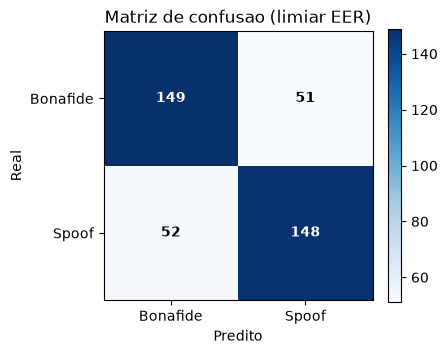

In [7]:
def compute_eer(scores: np.ndarray, labels: np.ndarray) -> tuple[float, float]:
    """Calcula o Equal Error Rate e o limiar correspondente.

    Usa a curva ROC e procura o ponto onde a taxa de falsos negativos (FNR = 1 - TPR) mais se
    aproxima da taxa de falsos positivos (FPR).

    Args:
        scores: Array (N,) com a probabilidade de spoof.
        labels: Array (N,) com os rotulos binarios (1 = spoof, 0 = bonafide).

    Returns:
        Tupla `(eer, threshold)`: o EER em fracao [0, 1] e o limiar de score que o atinge.
    """
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    return eer, float(thresholds[idx])


def evaluate(scores: np.ndarray, labels: np.ndarray, condition: str = "integro") -> dict[str, float]:
    """Consolida EER, MCC e Acuracia (em dois limiares) para um conjunto de scores.

    Args:
        scores: Array (N,) com a probabilidade de spoof.
        labels: Array (N,) com os rotulos binarios (1 = spoof, 0 = bonafide).
        condition: Rotulo textual da condicao avaliada (ex.: "integro", "mp3"), usado no relatorio.

    Returns:
        Dicionario com as chaves: `condition`, `eer` (%), `eer_threshold`, `mcc_eer`, `acc_eer`,
        `mcc_0.5`, `acc_0.5`.
    """
    eer, thr = compute_eer(scores, labels)
    pred_eer = (scores >= thr).astype(int)
    pred_half = (scores >= 0.5).astype(int)
    return {
        "condition": condition,
        "eer": eer * 100.0,
        "eer_threshold": thr,
        "mcc_eer": matthews_corrcoef(labels, pred_eer),
        "acc_eer": accuracy_score(labels, pred_eer),
        "mcc_0.5": matthews_corrcoef(labels, pred_half),
        "acc_0.5": accuracy_score(labels, pred_half),
    }


def plot_confusion(scores: np.ndarray, labels: np.ndarray, threshold: float, title: str) -> None:
    """Plota a matriz de confusao para um dado limiar de decisao.

    Args:
        scores: Array (N,) com a probabilidade de spoof.
        labels: Array (N,) com os rotulos binarios (1 = spoof, 0 = bonafide).
        threshold: Limiar de score acima do qual o audio e classificado como spoof.
        title: Titulo do grafico.

    Returns:
        None. Exibe o grafico via matplotlib.
    """
    preds = (scores >= threshold).astype(int)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["Bonafide", "Spoof"])
    ax.set_yticks([0, 1], ["Bonafide", "Spoof"])
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


clean_metrics = evaluate(spoof_scores, y_true, condition="integro")
print("=== Metricas zero-shot (audio integro) ===")
print(f"  EER            : {clean_metrics['eer']:.2f}%")
print(f"  MCC (limiar EER): {clean_metrics['mcc_eer']:+.3f}   | Acuracia: {clean_metrics['acc_eer'] * 100:.2f}%")
print(f"  MCC (limiar 0.5): {clean_metrics['mcc_0.5']:+.3f}   | Acuracia: {clean_metrics['acc_0.5'] * 100:.2f}%")

plot_confusion(spoof_scores, y_true, clean_metrics["eer_threshold"], "Matriz de confusao (limiar EER)")

## 7. Robustez: degradacoes do mundo real

Para simular ameacas realistas (Channing et al., 2024), criamos copias degradadas dos audios e
reavaliamos o detector:

- **Ruido gaussiano** a diferentes SNRs.
- **Compressao MP3** com baixa taxa de bits (perda).
- **Codec de telefonia G.711** (mu-law) com banda de 8 kHz.

Cada degradacao e uma funcao pura `audio -> audio`. Comparamos EER/MCC em cada condicao para
medir a queda de desempenho.

In [8]:
def add_gaussian_noise(audio: np.ndarray, sr: int, snr_db: float) -> tuple[np.ndarray, int]:
    """Adiciona ruido gaussiano branco a um dado SNR.

    Args:
        audio: Audio bruto (float32).
        sr: Taxa de amostragem (mantida na saida).
        snr_db: Relacao sinal-ruido alvo, em dB. Valores menores = mais ruido.

    Returns:
        Tupla `(audio_ruidoso, sr)`.
    """
    signal_power = float(np.mean(audio ** 2)) + 1e-12
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise = np.random.normal(0.0, np.sqrt(noise_power), size=audio.shape).astype(np.float32)
    return (audio + noise).astype(np.float32), sr


def mp3_compress(audio: np.ndarray, sr: int, bitrate: str = "16k") -> tuple[np.ndarray, int]:
    """Aplica compressao MP3 com perda (round-trip encode/decode) via pydub/ffmpeg.

    Args:
        audio: Audio bruto (float32), esperado no intervalo [-1, 1].
        sr: Taxa de amostragem.
        bitrate: Taxa de bits do MP3 (ex.: "16k", "32k"). Menor = mais perda.

    Returns:
        Tupla `(audio_comprimido, sr)`. O comprimento pode variar levemente; `preprocess`
        reajusta depois.
    """
    pcm16 = (np.clip(audio, -1.0, 1.0) * 32767.0).astype(np.int16)
    segment = AudioSegment(pcm16.tobytes(), frame_rate=sr, sample_width=2, channels=1)
    buffer = io.BytesIO()
    segment.export(buffer, format="mp3", bitrate=bitrate)
    buffer.seek(0)
    decoded = AudioSegment.from_file(buffer, format="mp3")
    samples = np.array(decoded.get_array_of_samples(), dtype=np.float32) / 32767.0
    return samples, sr


def g711_telephony(audio: np.ndarray, sr: int) -> tuple[np.ndarray, int]:
    """Simula um canal de telefonia tradicional/VoIP com o codec G.711 (mu-law).

    Reduz a banda para 8 kHz, aplica companding mu-law (encode + decode, 8 bits) e retorna a
    taxa de amostragem original.

    Args:
        audio: Audio bruto (float32).
        sr: Taxa de amostragem de entrada e de saida.

    Returns:
        Tupla `(audio_telefonia, sr)`.
    """
    waveform = torch.as_tensor(audio, dtype=torch.float32)
    narrow = torchaudio.functional.resample(waveform, sr, 8_000).clamp(-1.0, 1.0)
    encoded = torchaudio.functional.mu_law_encoding(narrow, quantization_channels=256)
    decoded = torchaudio.functional.mu_law_decoding(encoded, quantization_channels=256)
    restored = torchaudio.functional.resample(decoded, 8_000, sr)
    return restored.numpy().astype(np.float32), sr


def degrade_all(
    audios: list[np.ndarray],
    sample_rates: list[int],
    degradation,
) -> tuple[list[np.ndarray], list[int]]:
    """Aplica uma funcao de degradacao a todos os audios de uma lista.

    Args:
        audios: Lista de audios brutos.
        sample_rates: Taxas de amostragem paralelas.
        degradation: Callable `(audio, sr) -> (audio, sr)`.

    Returns:
        Tupla `(audios_degradados, sample_rates)`.
    """
    out_audios: list[np.ndarray] = []
    out_srs: list[int] = []
    for audio, sr in zip(audios, sample_rates):
        deg_audio, deg_sr = degradation(audio, sr)
        out_audios.append(deg_audio)
        out_srs.append(deg_sr)
    return out_audios, out_srs


# Cada condicao e um par (nome, funcao de degradacao) aplicado antes do pre-processamento.
degradation_conditions = {
    "ruido_snr20": lambda a, sr: add_gaussian_noise(a, sr, snr_db=20.0),
    "ruido_snr10": lambda a, sr: add_gaussian_noise(a, sr, snr_db=10.0),
    "mp3_16k": lambda a, sr: mp3_compress(a, sr, bitrate="16k"),
    "g711": g711_telephony,
}

set_seed()  # reprodutibilidade do ruido gaussiano
results = [clean_metrics]
for name, fn in degradation_conditions.items():
    deg_audios, deg_srs = degrade_all(eval_audios, eval_srs, fn)
    deg_scores = score_audios(detector, deg_audios, deg_srs, desc=f"Inferencia [{name}]")
    results.append(evaluate(deg_scores, y_true, condition=name))

results_df = pd.DataFrame(results).set_index("condition")
results_df

Inferencia [g711]: 100%|██████████| 50/50 [00:13<00:00,  3.80it/s]


,eer,eer_threshold,mcc_eer,acc_eer,mcc_0.5,acc_0.5
condition,,,,,,
integro,25.75,0.998126,0.485006,0.7425,0.129628,0.5425
ruido_snr20,31.25,0.996633,0.375005,0.6875,0.198559,0.5775
ruido_snr10,36.75,0.912054,0.265003,0.6325,0.222122,0.6025
mp3_16k,36.00,0.996005,0.280000,0.6400,0.038126,0.5125
g711,26.00,0.997843,0.480000,0.7400,0.138478,0.5450


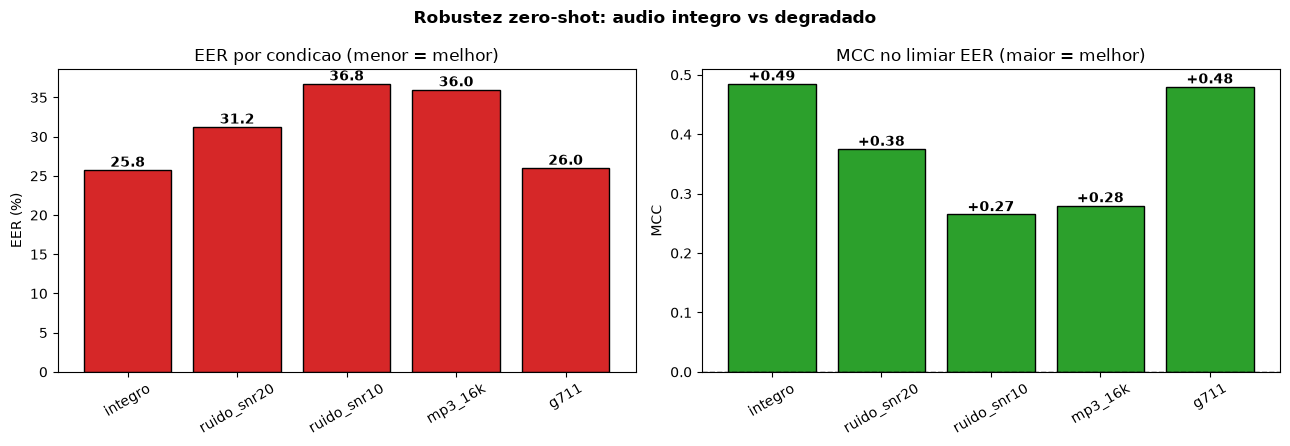

In [9]:
def plot_robustness(df: pd.DataFrame) -> None:
    """Plota EER e MCC por condicao de degradacao, lado a lado.

    Args:
        df: DataFrame indexado por `condition`, contendo as colunas `eer` (%) e `mcc_eer`.

    Returns:
        None. Exibe os graficos via matplotlib.
    """
    fig, (ax_eer, ax_mcc) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax_eer.bar(df.index, df["eer"], color="#d62728", edgecolor="black")
    ax_eer.set_title("EER por condicao (menor = melhor)")
    ax_eer.set_ylabel("EER (%)")
    ax_eer.tick_params(axis="x", rotation=30)
    for i, v in enumerate(df["eer"]):
        ax_eer.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")

    ax_mcc.bar(df.index, df["mcc_eer"], color="#2ca02c", edgecolor="black")
    ax_mcc.set_title("MCC no limiar EER (maior = melhor)")
    ax_mcc.set_ylabel("MCC")
    ax_mcc.axhline(0, color="black", linewidth=1, linestyle="--")
    ax_mcc.tick_params(axis="x", rotation=30)
    for i, v in enumerate(df["mcc_eer"]):
        ax_mcc.text(i, v, f"{v:+.2f}", ha="center", va="bottom", fontweight="bold")

    fig.suptitle("Robustez zero-shot: audio integro vs degradado", fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_robustness(results_df)

## 8. Explicabilidade I - GATR (Gradient Average Transformer Relevancy)

O GATR (Grinberg et al., 2025) explica a decisao no **dominio do tempo**: para cada camada do
transformer, calcula a matriz de atencao ponderada pelo seu gradiente em relacao ao logit alvo,
tira a media entre as cabecas (mantendo so contribuicoes positivas) e agrega as camadas. Projetamos
a relevancia por frame de volta na forma de onda (cada frame do wav2vec cobre ~20 ms / 320 amostras).

Implementacao: um gerenciador de contexto instala hooks temporarios nas camadas de auto-atencao do
fairseq, forcando a exposicao dos pesos de atencao e retendo seus gradientes; um `backward` a partir
do logit de spoof preenche `attn.grad`. Assim vemos em quais milissegundos (silencio, consoantes,
vogais) o detector se apoiou.

In [10]:
class AttentionCapture:
    """Gerenciador de contexto que captura os pesos de atencao (e seus gradientes) por camada.

    Enquanto ativo, substitui temporariamente o `forward` de cada modulo de auto-atencao do
    front-end fairseq para forcar `need_weights=True` / `need_head_weights=True` e reter o
    gradiente do tensor de atencao. Ao sair, restaura os `forward` originais.

    Attributes:
        layers: Lista de camadas do transformer cujas atencoes serao capturadas.
        attentions: Lista (preenchida durante o forward) de tensores de atencao por camada,
            cada um com shape (num_heads, batch, T, T) e com `retain_grad()` habilitado.
    """

    def __init__(self, layers: torch.nn.ModuleList) -> None:
        self.layers = layers
        self.attentions: list[torch.Tensor] = []
        self._originals: list = []

    def __enter__(self) -> "AttentionCapture":
        self.attentions = []
        self._originals = []
        for layer in self.layers:
            attn_module = layer.self_attn
            original = attn_module.forward
            self._originals.append((attn_module, original))

            def make_patched(orig):
                def patched(query, key=None, value=None, *args, **kwargs):
                    kwargs["need_weights"] = True
                    kwargs["need_head_weights"] = True
                    out, weights = orig(query, key, value, *args, **kwargs)
                    if weights is not None:
                        weights.retain_grad()
                        self.attentions.append(weights)
                    return out, weights
                return patched

            attn_module.forward = make_patched(original)
        return self

    def __exit__(self, *exc) -> bool:
        for module, original in self._originals:
            module.forward = original
        return False


def gatr_relevance(det: AntiDeepfakeDetector, waveform: torch.Tensor) -> np.ndarray:
    """Calcula a relevancia temporal (por frame) de um audio via GATR.

    Args:
        det: Detector encapsulado.
        waveform: Tensor 1-D ja pre-processado (num_samples,), no device do modelo.

    Returns:
        Array 1-D (T',) com a relevancia normalizada em [0, 1] por frame do wav2vec.

    Raises:
        RuntimeError: Se nenhum peso de atencao for capturado (incompatibilidade de versao do
            fairseq), sinalizando que a Oclusao (secao 9) deve ser usada como alternativa.
    """
    det.model.zero_grad(set_to_none=True)
    batch = waveform.unsqueeze(0).to(det.device)
    with torch.enable_grad(), AttentionCapture(det.transformer_layers) as capture:
        logits = det.logits(batch)
        logits[0, det.spoof_index].backward()
        captured = capture.attentions

    if not captured or all(a.grad is None for a in captured):
        raise RuntimeError("Nenhuma atencao/gradiente capturado; use a Oclusao (secao 9).")

    layer_relevances = []
    for attn in captured:
        if attn.grad is None:
            continue
        cam = (attn.detach() * attn.grad).mean(dim=0)  # media entre cabecas -> (batch, T, T)
        cam = cam.clamp(min=0.0)[0]                    # so contribuicoes positivas -> (T, T)
        layer_relevances.append(cam.mean(dim=0))       # importancia de cada frame-chave -> (T,)

    relevance = torch.stack(layer_relevances).mean(dim=0)  # agrega camadas -> (T,)
    relevance = relevance - relevance.min()
    denom = relevance.max()
    if denom > 0:
        relevance = relevance / denom
    return relevance.cpu().numpy()


def upsample_to_samples(frame_values: np.ndarray, num_samples: int = CFG.num_samples) -> np.ndarray:
    """Expande um vetor por frame para o comprimento em amostras da forma de onda.

    Args:
        frame_values: Array 1-D (T',) com um valor por frame do wav2vec.
        num_samples: Comprimento alvo, em amostras.

    Returns:
        Array 1-D (num_samples,) com os valores interpolados linearmente ao longo do tempo.
    """
    frame_positions = np.linspace(0, 1, num=len(frame_values))
    sample_positions = np.linspace(0, 1, num=num_samples)
    return np.interp(sample_positions, frame_positions, frame_values)


def plot_time_relevance(waveform: np.ndarray, relevance_frames: np.ndarray, title: str) -> None:
    """Plota a forma de onda com a relevancia GATR sobreposta e o espectrograma de Mel.

    Args:
        waveform: Forma de onda pre-processada (num_samples,).
        relevance_frames: Relevancia por frame (T',) retornada por `gatr_relevance`.
        title: Titulo da figura.

    Returns:
        None. Exibe os graficos via matplotlib.
    """
    duration = len(waveform) / CFG.sample_rate
    time_axis = np.linspace(0, duration, num=len(waveform))
    relevance = upsample_to_samples(relevance_frames, len(waveform))

    fig, (ax_wave, ax_mel) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax_wave.plot(time_axis, waveform, color="#333333", linewidth=0.6, alpha=0.8)
    ax_wave.fill_between(time_axis, waveform.min(), waveform.max(), where=relevance > 0,
                         color="red", alpha=0.0)  # base transparente para manter os limites
    twin = ax_wave.twinx()
    twin.fill_between(time_axis, 0, relevance, color="red", alpha=0.35, label="Relevancia GATR")
    twin.set_ylabel("Relevancia (norm.)")
    twin.set_ylim(0, 1.05)
    ax_wave.set_title(title)
    ax_wave.set_ylabel("Amplitude")
    twin.legend(loc="upper right")

    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=CFG.sample_rate, n_fft=400, hop_length=320, n_mels=80
    )(torch.as_tensor(waveform, dtype=torch.float32))
    mel_db = torchaudio.transforms.AmplitudeToDB()(mel).numpy()
    ax_mel.imshow(mel_db, aspect="auto", origin="lower", cmap="magma",
                  extent=[0, duration, 0, 80])
    ax_mel.set_title("Espectrograma de Mel")
    ax_mel.set_xlabel("Tempo (s)")
    ax_mel.set_ylabel("Bandas Mel")

    plt.tight_layout()
    plt.show()


def pick_example(y: np.ndarray, scores: np.ndarray, want_spoof: bool, correct: bool) -> int | None:
    """Escolhe o indice de um exemplo por categoria (spoof/bonafide, acerto/erro).

    Args:
        y: Rotulos binarios (1 = spoof).
        scores: Probabilidades de spoof.
        want_spoof: Se True, procura um audio spoof; senao, bonafide.
        correct: Se True, exige que o modelo tenha acertado (usando limiar 0.5).

    Returns:
        Indice do exemplo mais confiante que satisfaz os criterios, ou None se nao houver.
    """
    target_label = 1 if want_spoof else 0
    pred = (scores >= 0.5).astype(int)
    mask = (y == target_label) & ((pred == y) if correct else (pred != y))
    candidates = np.where(mask)[0]
    if len(candidates) == 0:
        return None
    ordered = candidates[np.argsort(scores[candidates])]
    return int(ordered[-1] if want_spoof else ordered[0])


# Explica um spoof detectado corretamente (True Positive) e um bonafide.
for descricao, want_spoof, correct in [("spoof detectado (TP)", True, True),
                                       ("bonafide (TN)", False, True)]:
    idx = pick_example(y_true, spoof_scores, want_spoof=want_spoof, correct=correct)
    if idx is None:
        print(f"[aviso] Nenhum exemplo para: {descricao}")
        continue
    wav = preprocess(eval_audios[idx], eval_srs[idx]).to(detector.device)
    try:
        rel = gatr_relevance(detector, wav)
        plot_time_relevance(
            wav.detach().cpu().numpy(), rel,
            title=f"GATR - {descricao} | idx={idx} | P(spoof)={spoof_scores[idx]:.2f}",
        )
    except RuntimeError as err:
        print(f"[GATR indisponivel] {err}")
        break

[GATR indisponivel] Nenhuma atencao/gradiente capturado; use a Oclusao (secao 9).


## 9. Explicabilidade II - Oclusao no dominio do tempo

Metodo simples e robusto (Fullwood & Monrose, 2025; Grinberg et al., 2025), independente da
arquitetura: deslizamos uma janela de poucos milissegundos, zeramos aquele trecho (piso de
energia) e medimos a **queda de confianca** de spoof. Onde a confianca despenca esta a regiao
vital para a decisao.

Como bonus, agregamos a importancia por oclusao sobre varios audios e a separamos em **fala** vs
**silencio** (usando VAD), reproduzindo a analise fala/nao-fala de Grinberg et al. e a ideia de
"contribuicao relativa" do notebook anterior.

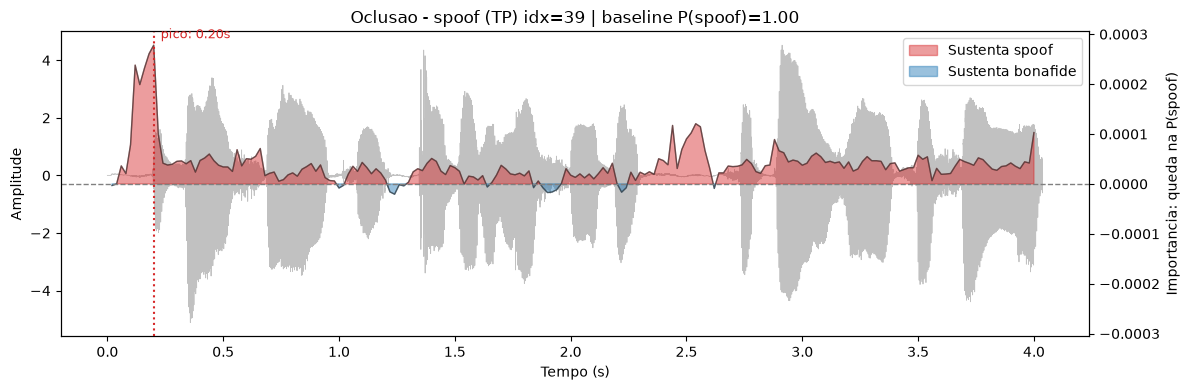

In [11]:
def occlusion_curve(
    det: AntiDeepfakeDetector,
    waveform: torch.Tensor,
    window_ms: float = 40.0,
    step_ms: float = 20.0,
    batch_size: int = 16,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Mede a queda de confianca de spoof ao ocluir janelas sucessivas do audio.

    Args:
        det: Detector encapsulado.
        waveform: Tensor 1-D ja pre-processado (num_samples,).
        window_ms: Largura da janela oclusa, em milissegundos.
        step_ms: Passo entre janelas consecutivas, em milissegundos.
        batch_size: Numero de versoes ocluidas avaliadas por lote.

    Returns:
        Tupla `(baseline, centers, drops)`:
            - `baseline`: probabilidade de spoof do audio integro.
            - `centers`: array (M,) com o centro de cada janela, em segundos.
            - `drops`: array (M,) com a queda de confianca (baseline - prob_oclusa) por janela.
    """
    baseline = float(det.spoof_prob_tensor(waveform.unsqueeze(0).to(det.device)).item())
    win = int(window_ms * CFG.sample_rate / 1000)
    step = int(step_ms * CFG.sample_rate / 1000)
    starts = list(range(0, len(waveform) - win + 1, step))

    centers: list[float] = []
    drops: list[float] = []
    for i in range(0, len(starts), batch_size):
        batch_starts = starts[i : i + batch_size]
        occluded = []
        for s in batch_starts:
            w = waveform.clone()
            w[s : s + win] = 0.0
            occluded.append(w)
        probs = det.spoof_prob_tensor(torch.stack(occluded).to(det.device)).cpu().numpy()
        drops.extend((baseline - probs).tolist())
        centers.extend([(s + win / 2) / CFG.sample_rate for s in batch_starts])
    return baseline, np.asarray(centers), np.asarray(drops)


def plot_occlusion(waveform: np.ndarray, baseline: float, centers: np.ndarray,
                   drops: np.ndarray, title: str) -> None:
    """Plota a forma de onda e a importancia por oclusao (area divergente).

    A curva de importancia e a queda na P(spoof) ao ocluir cada janela: valores positivos
    (vermelho) indicam que o trecho SUSTENTA a decisao de spoof; valores negativos (azul)
    indicam que o trecho empurra a predicao para bonafide.

    Args:
        waveform: Forma de onda pre-processada (num_samples,).
        baseline: Probabilidade de spoof do audio integro.
        centers: Centros das janelas, em segundos.
        drops: Queda de confianca por janela (baseline - P(spoof) ocluida).
        title: Titulo da figura.

    Returns:
        None. Exibe o grafico via matplotlib.
    """
    duration = len(waveform) / CFG.sample_rate
    time_axis = np.linspace(0, duration, num=len(waveform))

    fig, ax_wave = plt.subplots(figsize=(12, 4))
    ax_wave.plot(time_axis, waveform, color="#999999", linewidth=0.6, alpha=0.6)
    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_xlabel("Tempo (s)")

    twin = ax_wave.twinx()
    # Area divergente centrada em zero: quente = sustenta spoof, frio = sustenta bonafide.
    twin.fill_between(centers, 0, drops, where=drops >= 0, interpolate=True,
                      color="#d62728", alpha=0.45, label="Sustenta spoof")
    twin.fill_between(centers, 0, drops, where=drops < 0, interpolate=True,
                      color="#1f77b4", alpha=0.45, label="Sustenta bonafide")
    twin.plot(centers, drops, color="#333333", linewidth=1.0, alpha=0.7)
    twin.axhline(0, color="gray", linestyle="--", linewidth=1)

    # Eixo simetrico em torno do zero para o sinal (positivo/negativo) ficar honesto.
    max_abs = float(np.max(np.abs(drops))) if len(drops) else 1.0
    twin.set_ylim(-max_abs * 1.1, max_abs * 1.1)
    twin.set_ylabel("Importancia: queda na P(spoof)")

    # Marca a janela mais importante (maior queda positiva).
    if len(drops):
        top = int(np.argmax(drops))
        twin.axvline(centers[top], color="#d62728", linestyle=":", linewidth=1.5)
        twin.annotate(f"pico: {centers[top]:.2f}s", xy=(centers[top], drops[top]),
                      xytext=(5, 5), textcoords="offset points", fontsize=9, color="#d62728")

    twin.legend(loc="upper right")
    ax_wave.set_title(f"{title} | baseline P(spoof)={baseline:.2f}")
    plt.tight_layout()
    plt.show()


idx_occ = pick_example(y_true, spoof_scores, want_spoof=True, correct=True)
if idx_occ is not None:
    wav_occ = preprocess(eval_audios[idx_occ], eval_srs[idx_occ]).to(detector.device)
    base, cen, drp = occlusion_curve(detector, wav_occ)
    plot_occlusion(wav_occ.cpu().numpy(), base, cen, drp,
                   title=f"Oclusao - spoof (TP) idx={idx_occ}")
else:
    print("[aviso] Nenhum spoof detectado corretamente para a oclusao.")

Oclusao agregada (fala/silencio): 100%|██████████| 20/20 [01:46<00:00,  5.35s/it]

=== Importancia por oclusao: fala vs silencio ===
  Audios agregados      : 20
  Importancia media fala: -0.0048  (relativa: -27.2%)
  Import. media silencio: -0.0186  (relativa: +185.3%)


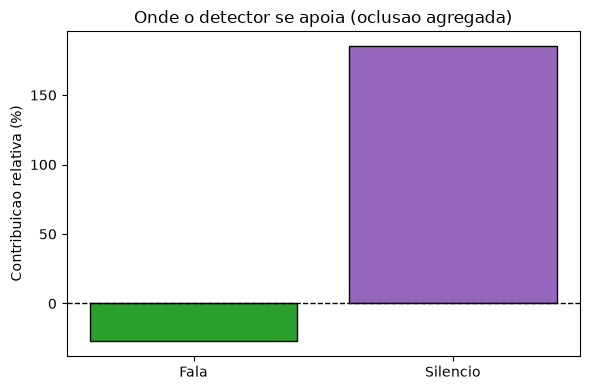

In [12]:
def vad_speech_frames(waveform: np.ndarray, sr: int = CFG.sample_rate, frame_ms: int = 20,
                      aggressiveness: int = 2) -> np.ndarray:
    """Rotula cada frame de 20 ms como fala (True) ou silencio (False) via WebRTC VAD.

    Args:
        waveform: Forma de onda (idealmente normalizada por pico) no intervalo [-1, 1].
        sr: Taxa de amostragem (deve ser 8/16/32/48 kHz para o WebRTC VAD).
        frame_ms: Duracao de cada frame, em ms (10, 20 ou 30).
        aggressiveness: Agressividade do VAD (0 = permissivo, 3 = rigoroso).

    Returns:
        Array booleano (F,) com um rotulo por frame de `frame_ms`.
    """
    vad = webrtcvad.Vad(aggressiveness)
    pcm = (np.clip(waveform, -1.0, 1.0) * 32767.0).astype(np.int16).tobytes()
    frame_bytes = int(sr * frame_ms / 1000) * 2
    labels = [
        vad.is_speech(pcm[i : i + frame_bytes], sr)
        for i in range(0, len(pcm) - frame_bytes + 1, frame_bytes)
    ]
    return np.asarray(labels, dtype=bool)


def aggregate_speech_vs_silence(
    det: AntiDeepfakeDetector,
    audios: list[np.ndarray],
    sample_rates: list[int],
    n_samples: int = 20,
    frame_ms: int = 20,
) -> dict[str, float]:
    """Agrega a importancia por oclusao e a separa em fala vs silencio (via VAD).

    Para cada audio, usa janelas de oclusao de `frame_ms` (alinhadas aos frames do VAD) e acumula
    a queda de confianca em cada categoria. Reporta a importancia media e a contribuicao relativa
    de cada categoria em relacao a media global (no espirito da RCQ).

    Args:
        det: Detector encapsulado.
        audios: Lista de audios brutos.
        sample_rates: Taxas de amostragem paralelas.
        n_samples: Quantos audios agregar (mantido baixo por custo computacional).
        frame_ms: Tamanho da janela/frame, em ms (deve casar com o VAD).

    Returns:
        Dicionario com importancia media (`mean_*`) e contribuicao relativa em % (`rel_*`) para
        fala e silencio, alem de `n_audios`.
    """
    speech_drops: list[float] = []
    silence_drops: list[float] = []

    for audio, sr in tqdm(list(zip(audios[:n_samples], sample_rates[:n_samples])),
                          desc="Oclusao agregada (fala/silencio)"):
        wav_model = preprocess(audio, sr)                    # para o modelo (layernorm)
        wav_vad = preprocess(audio, sr, norm_mode="peak")    # para o VAD (energia real)
        _, _, drops = occlusion_curve(det, wav_model, window_ms=frame_ms, step_ms=frame_ms)
        # preprocess ja reamostrou para CFG.sample_rate (16 kHz); o WebRTC VAD so aceita
        # 8/16/32/48 kHz, entao passamos a taxa pos-preprocess, nao a nativa (sr).
        labels = vad_speech_frames(wav_vad.numpy(), sr=CFG.sample_rate, frame_ms=frame_ms)
        m = min(len(labels), len(drops))
        drops, labels = drops[:m], labels[:m]
        speech_drops.extend(drops[labels].tolist())
        silence_drops.extend(drops[~labels].tolist())

    mean_speech = float(np.mean(speech_drops)) if speech_drops else 0.0
    mean_silence = float(np.mean(silence_drops)) if silence_drops else 0.0
    mean_all = float(np.mean(speech_drops + silence_drops)) if (speech_drops or silence_drops) else 0.0

    def relative(value: float) -> float:
        return 100.0 * (value - mean_all) / mean_all if mean_all != 0 else 0.0

    return {
        "n_audios": min(n_samples, len(audios)),
        "mean_fala": mean_speech,
        "mean_silencio": mean_silence,
        "rel_fala": relative(mean_speech),
        "rel_silencio": relative(mean_silence),
    }


agg = aggregate_speech_vs_silence(detector, eval_audios, eval_srs, n_samples=20)
print("=== Importancia por oclusao: fala vs silencio ===")
print(f"  Audios agregados      : {agg['n_audios']}")
print(f"  Importancia media fala: {agg['mean_fala']:.4f}  (relativa: {agg['rel_fala']:+.1f}%)")
print(f"  Import. media silencio: {agg['mean_silencio']:.4f}  (relativa: {agg['rel_silencio']:+.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Fala", "Silencio"], [agg["rel_fala"], agg["rel_silencio"]],
       color=["#2ca02c", "#9467bd"], edgecolor="black")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("Contribuicao relativa (%)")
ax.set_title("Onde o detector se apoia (oclusao agregada)")
plt.tight_layout()
plt.show()

## 10. Conclusoes

Resumo do que este notebook produz para o paper:

- **Zero-shot cross-lingual**: um detector wav2vec 2.0 XLS-R pre-treinado (sem qualquer treino em
  portugues) e avaliado diretamente no BRSpeech-DF, medindo **EER**, **MCC** e **Acuracia**.
- **Robustez do mundo real**: a tabela e os graficos comparam o desempenho no audio integro contra
  ruido gaussiano, compressao MP3 e telefonia G.711, evidenciando a queda sob degradacao.
- **Explicabilidade no tempo**: GATR (atencao x gradiente projetados na forma de onda) e Oclusao
  por janela deslizante mostram em quais trechos (fala vs silencio) o detector se apoia.

### Como estender / depurar
- Trocar o `CFG.checkpoint` por outro modelo da familia AntiDeepfake (ex.: `wav2vec-large-anti-deepfake`)
  ou ativar o bloco comentado do `W2V2-AASIST` para a narrativa "so ingles".
- Ajustar `CFG.n_per_class` para acelerar (menos audios) ou robustecer (mais audios) a avaliacao.
- Se o GATR falhar por incompatibilidade do fairseq, a Oclusao (secao 9) e a alternativa
  independente de arquitetura.
- Todas as funcoes sao puras e documentadas, entao podem ser testadas isoladamente celula a celula.